In [1]:
import pandas as pd
import seaborn as sns
import pingouin as pg 
from scipy.stats import chi2_contingency

/opt/conda/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
data = pd.read_csv('csv_data/melb_data.csv')

Вопрос:

Отличается ли цена недвижимости (Price) в зависимости от количества комнат (Rooms)?

In [3]:
data.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [4]:
data.isna().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [5]:
data[['Rooms', 'Price']].describe()

,Rooms,Price
count,13580.000000,1.358000e+04
mean,2.937997,1.075684e+06
std,0.955748,6.393107e+05
min,1.000000,8.500000e+04
25%,2.000000,6.500000e+05
50%,3.000000,9.030000e+05
75%,3.000000,1.330000e+06
max,10.000000,9.000000e+06


In [6]:
data.groupby('Rooms')['Price'].count()

Rooms
1      681
2     3648
3     5881
4     2688
5      596
6       67
7       10
8        8
10       1
Name: Price, dtype: int64

In [7]:
pg.normality(data, dv ='Price', group = 'Rooms')

/opt/conda/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5881.
  res = hypotest_fun_out(*samples, **kwds)
/opt/conda/lib/python3.9/site-packages/pingouin/distribution.py:242: UserWarning: Group 10 has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")


,W,pval,normal
Rooms,,,
2,0.840256,2.170937e-51,False
3,0.862086,6.441531e-58,False
4,0.883544,5.255669e-41,False
1,0.629870,8.267894e-36,False
6,0.770441,7.238064e-09,False
5,0.899841,2.659195e-19,False
8,0.893154,2.503064e-01,True
7,0.843269,4.828455e-02,False
10,NaN,NaN,False


Rooms
1     AxesSubplot(0.125,0.125;0.775x0.755)
2     AxesSubplot(0.125,0.125;0.775x0.755)
3     AxesSubplot(0.125,0.125;0.775x0.755)
4     AxesSubplot(0.125,0.125;0.775x0.755)
5     AxesSubplot(0.125,0.125;0.775x0.755)
6     AxesSubplot(0.125,0.125;0.775x0.755)
7     AxesSubplot(0.125,0.125;0.775x0.755)
8     AxesSubplot(0.125,0.125;0.775x0.755)
10    AxesSubplot(0.125,0.125;0.775x0.755)
Name: Price, dtype: object

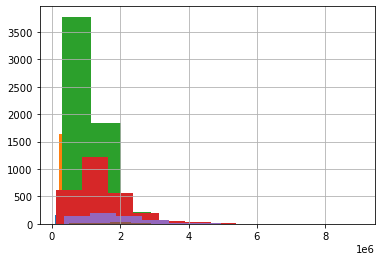

In [8]:
data.groupby('Rooms')['Price'].hist()

In [9]:
pg.homoscedasticity(data, dv ='Price', group = 'Rooms')

,W,pval,equal_var
levene,204.02762,0.0,False


Так как выборки имеют ненормальное распределение, дисперсии неравные, мы возьмем однофакторный ANOVA Уэлча для сравнения всех груп между собой, если пнадобится далее для post-hoc выберем
тест Уэлча

In [10]:
pg.welch_anova(data, dv ='Price', between = 'Rooms')

,Source,ddof1,ddof2,F,p-unc,np2
0,Rooms,8,97.992461,726.655862,1.218595e-83,0.252825


Видим наличие статистически значимых различий, проведем попарное сравнение.

In [11]:
stats = pg.pairwise_tests(data, dv ='Price', between = 'Rooms', padjust='fdr_bh')

/opt/conda/lib/python3.9/site-packages/pingouin/bayesian.py:152: RuntimeWarning: divide by zero encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)
/opt/conda/lib/python3.9/site-packages/pingouin/bayesian.py:152: RuntimeWarning: divide by zero encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)
/opt/conda/lib/python3.9/site-packages/pingouin/bayesian.py:152: RuntimeWarning: divide by zero encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)


In [12]:
stats[stats['p-corr'] > 0.05]

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
19,Rooms,3,8,False,True,-1.792955,7.006961,two-sided,0.116033,0.149185,fdr_bh,1.157,-1.047706
23,Rooms,4,7,False,True,-1.584673,9.041714,two-sided,0.147346,0.182912,fdr_bh,0.836,-0.635202
24,Rooms,4,8,False,True,-0.535562,7.033784,two-sided,0.608771,0.664113,fdr_bh,0.375,-0.210541
26,Rooms,5,6,False,True,0.149667,78.429596,two-sided,0.881411,0.881411,fdr_bh,0.143,0.020995
27,Rooms,5,7,False,True,-0.166823,9.327436,two-sided,0.871070,0.881411,fdr_bh,0.314,-0.051309
28,Rooms,5,8,False,True,0.902487,7.265278,two-sided,0.395732,0.474879,fdr_bh,0.459,0.272429
30,Rooms,6,7,False,True,-0.217396,12.869239,two-sided,0.831308,0.880209,fdr_bh,0.332,-0.065527
31,Rooms,6,8,False,True,0.764305,10.155430,two-sided,0.462075,0.519834,fdr_bh,0.435,0.227727
33,Rooms,7,8,False,True,0.757796,15.823449,two-sided,0.459711,0.519834,fdr_bh,0.504,0.337087
35,Rooms,8,10,False,True,2.392986,7.000000,two-sided,0.047958,0.063944,fdr_bh,1.958,0.846048


Вывод: при попраном сравнении каждой из групп, статистическая значимость проявилась у большинства, остальные имеют p-value до 0.8 (пограничное), что может свидетельствовать о недостаточной выборке (комнаты 7-10, количество наблюдений очень мало < 10, как раз пары с этими значениями мы получили не значимыми). Нужна дополнительная проверка, сейчас можно утверждать о наличии статистической значимости между количеством комнат и ценой помещения. 

In [13]:
table = data[data['Rooms'] < 7]

In [15]:
pg.homoscedasticity(table, dv ='Price', group = 'Rooms')

,W,pval,equal_var
levene,324.460548,0.0,False


In [16]:
pg.welch_anova(table, dv ='Price', between = 'Rooms')

,Source,ddof1,ddof2,F,p-unc,np2
0,Rooms,5,639.524144,1209.232889,4.446591e-323,0.252144


In [17]:
stats_corr = pg.pairwise_tests(table, dv ='Price', between = 'Rooms', padjust='fdr_bh')

/opt/conda/lib/python3.9/site-packages/pingouin/bayesian.py:152: RuntimeWarning: divide by zero encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)
/opt/conda/lib/python3.9/site-packages/pingouin/bayesian.py:152: RuntimeWarning: divide by zero encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)
/opt/conda/lib/python3.9/site-packages/pingouin/bayesian.py:152: RuntimeWarning: divide by zero encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)


In [18]:
stats_corr[stats_corr['p-corr'] > 0.05]

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
14,Rooms,5,6,False,True,0.149667,78.429596,two-sided,0.881411,0.881411,fdr_bh,0.143,0.020995


Действительно, убрав критически низкие значения, мы получили  только один не значимый результат: между группами 5 и 6. 